# Laboratório - Busca Local usando Simulated annealing

---


## Ajustando ambiente

In [ ]:
import random
import math

## Sumário

* Motivação
* Exemplo prático
* Perfil de custo computacional
* Key takeaways
* Referências

---


## Motivação

No nosso estudo sobre **Hill Climbing**, vimos que sua principal limitação é a tendência de ficar preso em máximos locais. O algoritmo, por ser "ganancioso", só se move para estados melhores, o que o impede de explorar a "paisagem de busca" de forma completa.

A **Têmpera Simulada** ou **Recozimento Simulado** (do inglês, Simulated annealing) a partir da introdução de um elemento de probabilidade que permite ao algoritmo aceitar um movimento que piora a solução. A probabilidade de aceitar um movimento ruim é alta no início e diminui gradualmente, um processo análogo ao "resfriamento" de um metal. Isso permite que o algoritmo escape de máximos ou mínimos locais e explore diferentes áreas do espaço de busca.

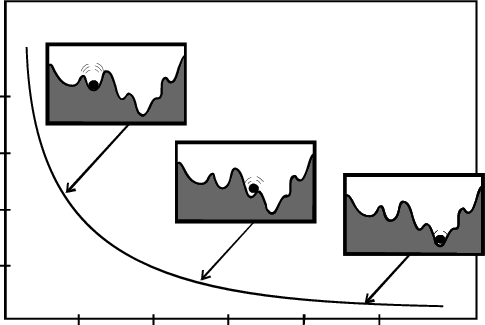

#### Intuição sobre o método

Uma analogia valida para o algoritmo de têmpera está no processo metalúrgico de aquecimento e resfriamento de materiais (recozimento) para fortalecer e uniformizar sua estrutura. A ideia é que, a uma alta temperatura, as partículas de um metal têm muita energia e podem se mover livremente. À medida que a temperatura cai, a mobilidade diminui e as partículas se acomodam em uma estrutura cristalina estável, o que resulta em um estado de baixa energia.

No mundo da otimização, a "temperatura" controla a probabilidade de aceitar um movimento que piora a solução.

* **Alta Temperatura:** O algoritmo tem uma alta probabilidade de aceitar um movimento que leva a um estado pior. Isso permite que ele "salte" para fora de máximos/mínimos locais e explore novas áreas da paisagem de busca.

* **Baixa Temperatura:** A probabilidade de aceitar um movimento ruim diminui. O algoritmo começa a se comportar de forma mais parecida com o Hill Climbing, concentrando-se em movimentos que melhoram a solução e se acomodando em um estado de baixa energia (poucos ataques).



## Exemplo prático

O Problema das 8 Rainhas é um desafio de otimização: posicionar 8 rainhas em um tabuleiro de xadrez de 8x8 de forma que nenhuma delas ataque a outra. Uma rainha ataca outras na mesma linha, coluna ou diagonal.

### Representação do Estado

Vamos representar o tabuleiro como uma lista de 8 posições. O índice da lista representa a coluna (0 a 7) e o valor em cada posição representa a linha da rainha (0 a 7). Por exemplo, a lista [6, 4, 2, 0, 5, 7, 1, 3].

Aqui está o detalhamento:

* Coluna 0: Rainha na linha 6
* Coluna 1: Rainha na linha 4
* Coluna 2: Rainha na linha 2
* Coluna 3: Rainha na linha 0
* Coluna 4: Rainha na linha 5
* Coluna 5: Rainha na linha 7
* Coluna 6: Rainha na linha 1
* Coluna 7: Rainha na linha 3



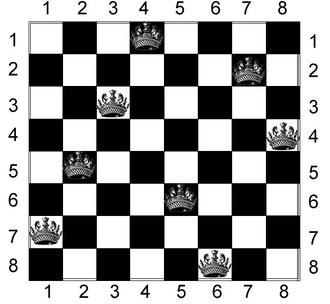

Considerem a indexação iniciada conforme o padrão do Python. Logo, a primeira posição é representada pelo zero.

### Função de Avaliação (Heurística)

Iremos utilizar a mesma função de avaliação baseada nos pares de rainhas que se atacam. O objetivo do algoritmo é minimizar este número, até que ele seja 0.

In [ ]:
def count_attacks(board):
    """Funcao que calcula quando ataques entre as rainhas."""
    attacks = 0
    n = len(board)
    for i in range(n):
        for j in range(i + 1, n):
            # Verifica ataques em linha
            if board[i] == board[j]:
                attacks += 1
            # Verifica ataques na diagonal
            elif abs(i - j) == abs(board[i] - board[j]):
                attacks += 1
    return attacks

### Implementação do Recozimento Simulado

In [ ]:
def simulated_annealing(num_queens, initial_temp=100.0, cooling_rate=0.99):
    """
    Resolve o problema das n rainhas usando Têmpera Simulada.

    Args:
        num_queens (int): O numero de rainhas no tabuleiro.
        initial_temp (float): A temperatura inicial.
        cooling_rate (float): A taxa de resfriamento.

    Returns:
        tuple: A solucao final e o numero de ataques.
    """
    # Gera uma solucao inicial aleatoria
    current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]
    current_attacks = count_attacks(current_board)
    temperature = initial_temp

    while temperature > 0.001:
        # Verifica se a solucao ideal foi encontrada
        if current_attacks == 0:
            print("Success. Optimal solutation was found.")
            return current_board, current_attacks

        # Gera um vizinho aleatorio
        neighbor = list(current_board)
        col_to_move = random.randint(0, num_queens - 1)
        new_row = random.randint(0, num_queens - 1)
        neighbor[col_to_move] = new_row
        neighbor_attacks = count_attacks(neighbor)

        # Calcula a diferenca na funcao de avaliacao (custo)
        delta_attacks = current_attacks - neighbor_attacks

        # Se o vizinho for melhor, aceite-o
        if delta_attacks > 0:
            current_board = neighbor
            current_attacks = neighbor_attacks
        else:
            # Aceite o vizinho pior com uma probabilidade
            # delta_attacks <= 0, numero de ataques aumenta
            probability = math.exp(delta_attacks / temperature)
            if random.random() < probability:
                current_board = neighbor
                current_attacks = neighbor_attacks

        # Resfria o sistema
        temperature *= cooling_rate

    print("\nThe algorithm has stopped. The final state can be a local or global maximum.")
    return current_board, current_attacks

In [ ]:
final_solution, final_attacks = simulated_annealing(8)
print("\nFinal Solution:")
print(f"Board configuration: {final_solution}")
print(f"Attacks: {final_attacks}")

Success. Optimal solutation was found.

Final Solution:
Board configuration: [3, 6, 0, 7, 4, 1, 5, 2]
Attacks: 0


#### Explicação

1.  **def simulated_annealing(num_queens, initial_temp=100.0, cooling_rate=0.99):**
> Define a função simulated_annealing. Ela aceita o número de rainhas (num_queens) e dois parâmetros cruciais para o algoritmo: a temperatura inicial (initial_temp) e a taxa de resfriamento (cooling_rate).

3.  **current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]**
> Gera a **solução inicial aleatória** do tabuleiro, servindo como o ponto de partida para a busca.

4.  **current_attacks = count_attacks(current_board)**
> Avalia a qualidade da solução inicial, calculando o número de ataques para saber o "custo" inicial.

5.  **temperature = initial_temp**
> Inicializa a variável temperature. Ela será o fator-chave que controla a probabilidade de aceitar movimentos que pioram a solução.

6.  **while temperature > 0.001:**
> Inicia o loop principal do algoritmo. A busca continua enquanto a temperatura estiver acima de um limite muito pequeno, simulando o processo de resfriamento gradual.

7.  **if current_attacks == 0:**
> Uma verificação de parada imediata. Se o número de ataques for 0, uma solução ideal foi encontrada, e não há necessidade de continuar a busca.

8.  **print("\nSucesso! Solucao otima encontrada.")**
> Imprime uma mensagem para indicar que a solução perfeita foi alcançada.

9.  **return current_board, current_attacks**
> Retorna a solução ideal e encerra a função.

10. **neighbor = list(current_board)**
> Cria uma cópia do tabuleiro atual. Isso é necessário para que a modificação de um vizinho não altere o tabuleiro atual.

11. **col_to_move = random.randint(0, num_queens - 1)**
> Seleciona aleatoriamente uma coluna para mover uma rainha.

12. **new_row = random.randint(0, num_queens - 1)**
> Seleciona aleatoriamente uma nova linha para a rainha na coluna escolhida.

13. **neighbor[col_to_move] = new_row**
> Cria o vizinho ao mover a rainha para a nova linha.

14. **neighbor_attacks = count_attacks(neighbor)**
> Avalia a qualidade do vizinho gerado.

15. **delta_attacks =  current_attacks - neighbor_attacks**
> Calcula a **diferença no número de ataques** entre o vizinho e o estado atual. Um valor negativo indica uma melhoria, e um valor positivo, uma piora.

16. **if delta_attacks > 0:**
> A primeira regra de aceitação. Se o vizinho for uma **melhoria** (tiver menos ataques), ele é sempre aceito.

17. **current_board = neighbor**
> Atualiza o tabuleiro atual para o vizinho, pois ele é melhor.

18. **current_attacks = neighbor_attacks**
> Atualiza a contagem de ataques.

19. **else:**
> Este bloco é executado se o vizinho **não for uma melhoria** (piorou ou é igual).

20. **probability = math.exp(delta_attacks / temperature)**
> Calcula a **probabilidade de aceitar um movimento pior**. A probabilidade é alta quando a temperatura é alta e a piora é pequena. Ela diminui à medida que o sistema "esfria" e a piora aumenta.

21. **if random.random() < probability:**
> Testa se o movimento ruim será aceito. Um número aleatório é gerado entre 0 e 1, e se for menor que a probabilidade calculada, o movimento é aceito.

22. **current_board = neighbor**
> Atualiza o tabuleiro atual com o vizinho pior, se a condição da linha anterior for verdadeira.

23. **current_attacks = neighbor_attacks**
> Atualiza a contagem de ataques, mesmo que tenha aumentado.

24. **temperature *= cooling_rate**
> **Resfria o sistema**. A temperatura é multiplicada pela taxa de resfriamento (normalmente um valor entre 0 e 1), garantindo que a probabilidade de aceitar movimentos piores diminua a cada iteração.

25. **print("\nO algoritmo parou. O estado final pode ser um maximo local ou global.")**
> Se o loop terminar por causa da temperatura (linha 6), esta mensagem é impressa.

26. **return current_board, current_attacks**
> A função retorna a solução final encontrada e o seu número de ataques.

### Visualizar tabuleiro

In [ ]:
# @title Função para gerar tabuleiro
def print_board(board):
    """
    Gera e exibe uma representacao visual do tabuleiro de xadrez como uma imagem.

    Args:
        board (list): Uma lista de 8 posicoes, onde o indice e a coluna
                      e o valor e a linha da rainha.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    n = len(board)
    board_image = np.zeros((n, n, 3), dtype=np.uint8)

    # Define as cores dos quadrados do tabuleiro
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                board_image[i, j] = [255, 255, 255]  # Branco
            else:
                board_image[i, j] = [169, 169, 169]  # Cinza

    plt.imshow(board_image)

    # Desenha as rainhas
    for i in range(n):
        plt.text(i, n - 1 - board[i], '♕', ha='center', va='center', fontsize=20, color='black')

    # Adiciona titulos e rotulos
    plt.title("Tabuleiro de Xadrez com 8 Rainhas")
    plt.xticks(np.arange(n))
    plt.yticks(np.arange(n), labels=np.arange(n-1, -1, -1))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

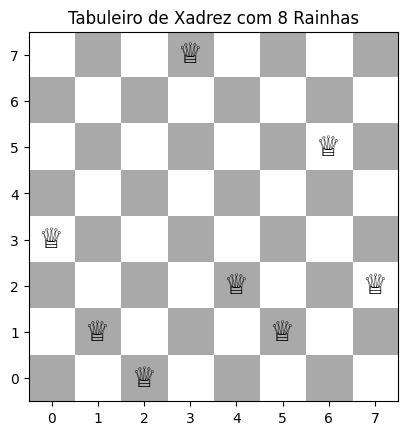

In [ ]:
print_board(board = [3,1,0,7,2,1,5,2])
# [3, 6, 0, 7, 4, 1, 5, 2]


## Key Takeways

O Simulated annealing foi desenvolvido para superar uma limitação fundamental de outros algoritmos de busca local, como a busca em encosta (hill climbing). Algoritmos de busca em encosta são vulneráveis a ficarem presos em "máximos locais" (ou "mínimos locais" se o objetivo for minimizar o custo) porque eles sempre se movem para estados com valor mais alto (ou custo mais baixo) e param quando não há nenhum vizinho com um valor melhor.


O algoritmo consegue escapar de ótimos locais por causa da sua natureza probabilística. A grande sacada é que ele não é puramente ganancioso, como o Hill Climbing. No início, ele é "imprudente" o suficiente para dar um passo para trás, se necessário, na esperança de encontrar um caminho melhor.

A chave está na fórmula de probabilidade que já vimos:

`P = e^-ΔE/T`, onde ΔE deve ser um valor negativo.

#### Compreendendo a função de custo

Como mencionando, no contexto do algoritmo de Têmpera/Recozimento Simulado, o **ΔE** é uma medida da mudança na avaliação (ou custo) entre o estado atual e um estado sucessor proposto. Ele é calculado como a **diferença entre o valor do estado atual e o valor do próximo estado**:

`ΔE = VALUE(current) – VALUE(next)`

Vamos analisar o que significa ΔE ser positivo ou negativo:

*   **ΔE Positiva (ΔE > 0)**:
    *   Significa que **VALUE(current) > VALUE(next)**.
    *   Isso indica que o **estado sucessor (`next`) tem um custo menor** do que o estado atual (`current`).
    *   É um **movimento que melhora a situação** (reduz o custo).
    *   Quando ΔE é positivo, o algoritmo de Simulated Annealing **sempre aceita a mudança** para o estado sucessor (`current` se torna `next`).

*   **ΔE Negativa (ΔE < 0)**:
    *   Significa que **VALUE(current) < VALUE(next)**.
    *   Isso indica que o **estado sucessor (`next`) tem um custo maior** do que o estado atual (`current`).
    *   É um **movimento que piora a situação** ("badness" do movimento).
    *   Quando ΔE é negativo, o algoritmo **não descarta automaticamente o movimento**. Em vez disso, ele o aceita com uma **probabilidade** que diminui exponencialmente com a "ruindade" do movimento (o quão pior ele é) e com a diminuição da "temperatura" (T).

No início, quando a temperatura T é alta, movimentos "ruins" são mais propensos a serem permitidos. Conforme T diminui, esses movimentos se tornam menos prováveis. Essa característica é crucial para que o Têmpera Simulada possa escapar de mínimos locais, permitindo que o algoritmo explore outras regiões do espaço de busca em vez de ficar preso.

#### Escape de Mínimos Locais

A Têmpera Simulada é utilizada para escapar de mínimos locais quando o objetivo é minimizar uma função de custo. No problema das 8-Rainhas, a função de custo é o **número de ataques**.

#### Resumo

* **Melhor que Hill Climbing:** A Têmpera Simulada é uma melhoria direta sobre o Hill Climbing porque ela consegue escapar de máximos locais, tornando-a mais propensa a encontrar uma solução globalmente ótima.

* **Aceitação Probabilística:** A essência do algoritmo é a probabilidade de aceitar um movimento pior, calculada pela fórmula P=e^−ΔE/T. Esta é a "magia" que permite a exploração.

* **Parâmetros Cruciais:** O desempenho depende criticamente dos parâmetros de controle, especialmente a temperatura inicial e a taxa de resfriamento. A escolha desses valores é crucial para o sucesso.

* **Analogia do Alpinista:** A Têmpera Simulada é como um alpinista que, no início, aceita descer para explorar um vale na esperança de encontrar um pico mais alto. À medida que ele se cansa (a temperatura cai), ele só aceita subir.



## Referências

1. Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern Approach. Prentice Hall.
2. Wikipedia: Hill-climbing algorithm
3. GeeksforGeeks: N-Queen Problem using Hill Climbing